| No. Presensi | Nama               | NIM        | Kelas   |
| ------------ | ------------------ | ---------- | ------- |
| 08           | Dedy Bayu Setiawan | 2341720041 | TI - 3H |


## 3. Buat Global Threshold (BINARY, BINARY_INV, TRUNC, TOZERO, TOZERO_INV), dengan threshold= 170, secara manual sesuai dengan deskripsi dari grafik yang ditunjukkan di atas.

Manual

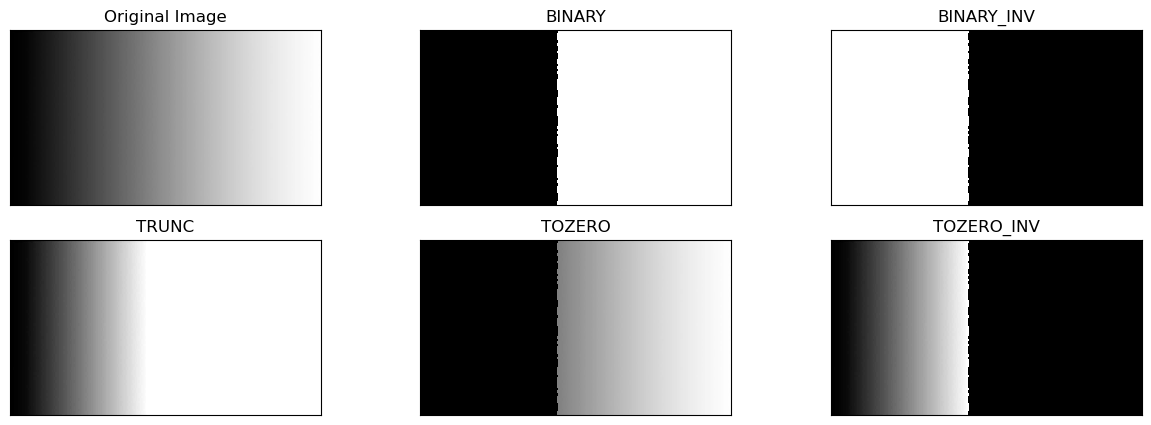

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

filename = '../images/gradient.jpg'
img = Image.open(filename).convert('L')  
img = np.array(img)

thresh = 127  

thresh1 = np.where(img > thresh, 255, 0) # BINARY: jika pixel > thresh maka 255, else 0
thresh2 = np.where(img > thresh, 0, 255) # BINARY_INV: kebalikan dari BINARY
thresh3 = np.where(img > thresh, thresh, img) # TRUNC: jika pixel > thresh maka nilai = thresh, else tetap
thresh4 = np.where(img > thresh, img, 0) # TOZERO: jika pixel <= thresh maka 0, else tetap
thresh5 = np.where(img > thresh, 0, img) # TOZERO_INV: jika pixel > thresh maka 0, else tetap

# 3. Menampilkan hasil
titles = ['Original Image','BINARY','BINARY_INV','TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

plt.figure(figsize=(15,5))
for i in range(len(images)):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], cmap='gray', interpolation='nearest')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.show()


OpenCV

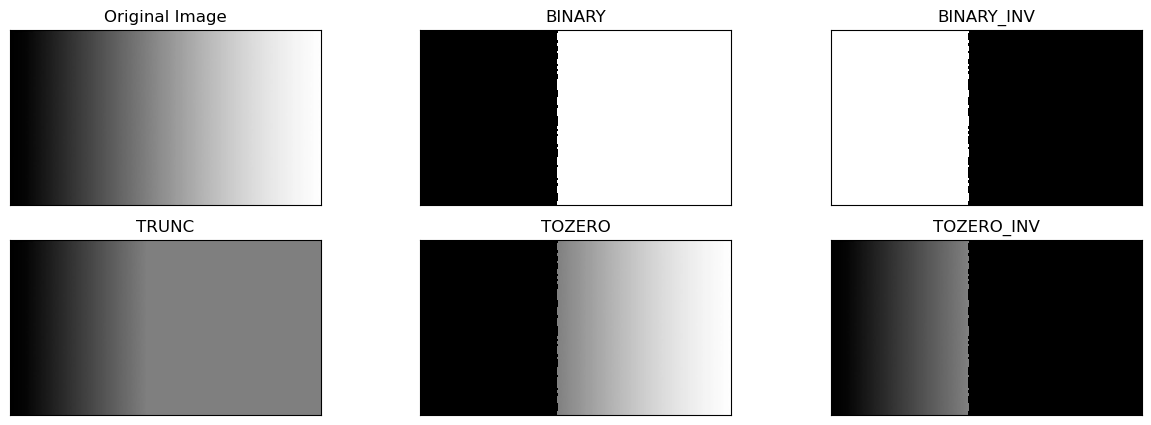

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

filename = ('../images/gradient.jpg')
img = cv.imread(filename)
thresh = 127 #nilai Threshold yang ditentukan

#1. thresh1 jika pixel di img>127, maka thresh1 bernilai 1(putih) selain itu bernilai 0(hitam)
ret,thresh1 = cv.threshold(img,thresh,255,cv.THRESH_BINARY)

#2. thresh2 adalah binary threshold inverse
ret,thresh2 = cv.threshold(img,thresh,255,cv.THRESH_BINARY_INV)

#3. Threshold Truncate
ret,thresh3 = cv.threshold(img,thresh,255,cv.THRESH_TRUNC)

#4. Threshold Tozero
ret,thresh4 = cv.threshold(img,thresh,255,cv.THRESH_TOZERO)

#5. Threshold Tozero Inverse
ret,thresh5 = cv.threshold(img,thresh,255,cv.THRESH_TOZERO_INV)
titles = ['Original Image','BINARY','BINARY_INV','TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]
plt.figure(figsize = (15,5))
for i in range(len(images)):
    plt.subplot(2,3,i+1),plt.imshow(images[i],'gray', interpolation='nearest')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

Nilai threshold Otsu: 165


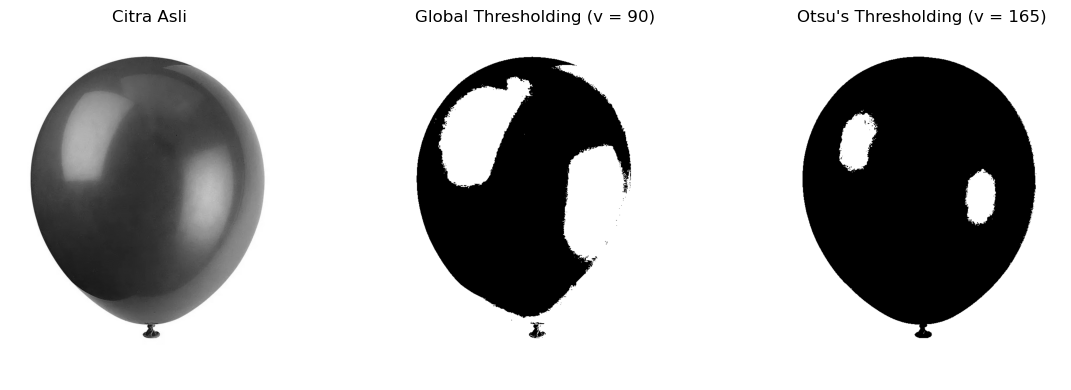

In [5]:
from PIL import Image

# 1. Baca gambar
img = Image.open('../images/balloon.jpg').convert('L')
img_np = np.array(img)

# 2. Hitung histogram dan probabilitas tiap intensitas
hist, bins = np.histogram(img_np.flatten(), bins=256, range=(0, 256))
total = img_np.size
prob = hist / total

# 3. Inisialisasi variabel untuk Otsu
current_max, threshold = 0, 0
sum_total, sum_foreground, weight_background = 0, 0, 0

for i in range(256):
    sum_total += i * prob[i]

# 4. Loop semua nilai threshold 0–255
for t in range(256):
    weight_background += prob[t]
    if weight_background == 0:
        continue
    weight_foreground = 1 - weight_background
    if weight_foreground == 0:
        break

    sum_foreground += t * prob[t]

    mean_background = sum_foreground / weight_background
    mean_foreground = (sum_total - sum_foreground) / weight_foreground

    # Variance antar kelas
    var_between = weight_background * weight_foreground * (mean_background - mean_foreground) ** 2

    # Cari nilai maksimum
    if var_between > current_max:
        current_max = var_between
        threshold = t

# 5. Terapkan threshold hasil Otsu
otsu_result = (img_np > threshold).astype(np.uint8) * 255

print(f"Nilai threshold Otsu: {threshold}")

# 6. Bandingkan dengan global threshold manual (misal v = 90)
v_global = 90
global_result = (img_np > v_global).astype(np.uint8) * 255

# 7. Tampilkan hasil
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img_np, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(global_result, cmap='gray')
plt.title(f'Global Thresholding (v = {v_global})')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(otsu_result, cmap='gray')
plt.title(f"Otsu's Thresholding (v = {threshold})")
plt.axis('off')

plt.tight_layout()
plt.show()


Nilai threshold Otsu: 165.0


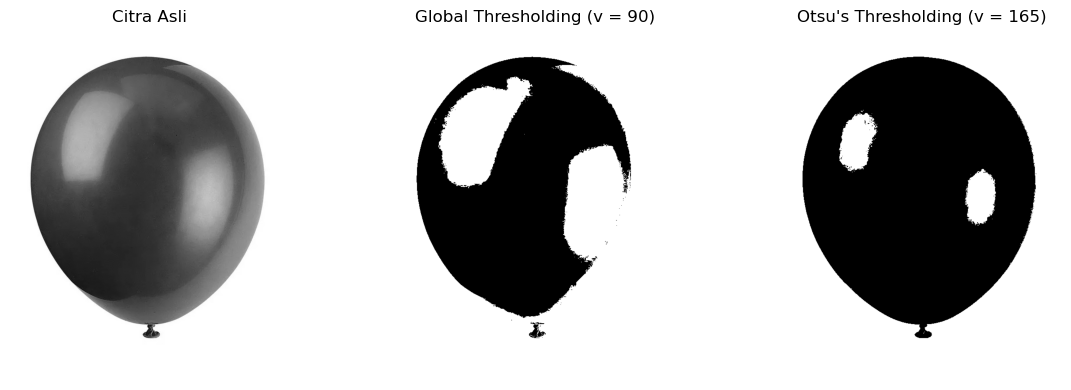

In [6]:
import cv2
import matplotlib.pyplot as plt

# 1. Baca gambar dalam mode grayscale
img = cv2.imread('../images/balloon.jpg', cv2.IMREAD_GRAYSCALE)

# 2. Global Threshold biasa (misal v = 90)
v_global = 90
_, global_thresh = cv2.threshold(img, v_global, 255, cv2.THRESH_BINARY)

# 3. Otsu Thresholding (tanpa memberi nilai ambang manual)
otsu_val, otsu_thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 4. Tampilkan nilai threshold hasil Otsu
print(f"Nilai threshold Otsu: {otsu_val}")

# 5. Tampilkan hasilnya
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(global_thresh, cmap='gray')
plt.title(f'Global Thresholding (v = {v_global})')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(otsu_thresh, cmap='gray')
plt.title(f"Otsu's Thresholding (v = {int(otsu_val)})")
plt.axis('off')

plt.tight_layout()
plt.show()


## 5 Buat histogram dari citra tersegmentasi, Histogram hanya pada foreground image saja. Gunakan image tobacco.jpg yang sudah disediakan di folder images.

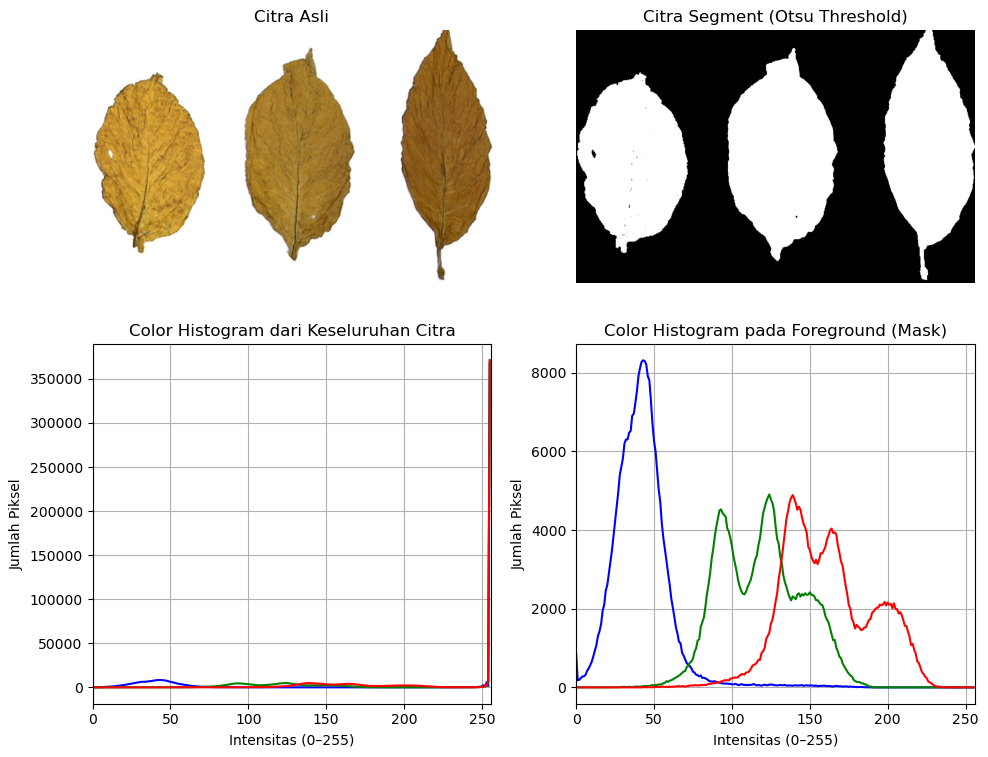

In [7]:
def colorHist(hist, title):
    for color in colors:
        plt.plot(hist[color], color=color)
    plt.title(title)
    plt.xlabel('Intensitas (0–255)')
    plt.ylabel('Jumlah Piksel')
    plt.xlim([0, 256])
    plt.grid(True)
    

# 1. Baca gambar
img = cv2.imread('../images/tobacco.jpg')

# 2. Konversi ke grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 3. Segmentasi dengan Otsu Threshold
_, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 4. Pisahkan channel warna
b, g, r = cv2.split(img)

# 5. Histogram dari keseluruhan citra untuk setiap channel
colors = ('b', 'g', 'r')
hist_full = {}
for (chan, color) in zip((b, g, r), colors):
    hist_full[color] = cv2.calcHist([chan], [0], None, [256], [0, 256])

# 6. Histogram hanya dari foreground (pakai mask)
hist_fg = {}
for (chan, color) in zip((b, g, r), colors):
    hist_fg[color] = cv2.calcHist([chan], [0], mask, [256], [0, 256])


plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(mask, cmap='gray')
plt.title('Citra Segment (Otsu Threshold)')
plt.axis('off')

plt.subplot(2, 2, 3)
colorHist(hist_full, 'Color Histogram dari Keseluruhan Citra')

plt.subplot(2, 2, 4)
colorHist(hist_fg, 'Color Histogram pada Foreground (Mask)')

plt.tight_layout()
plt.show()


## 6. Lakukan segmentasi warna pada image "peppers.jpg", munculkan hanya warna yang kuning saja. (Petunjuk: anda dapat gunakan K-Means untuk menampilkan hanya warna tertentu saja)

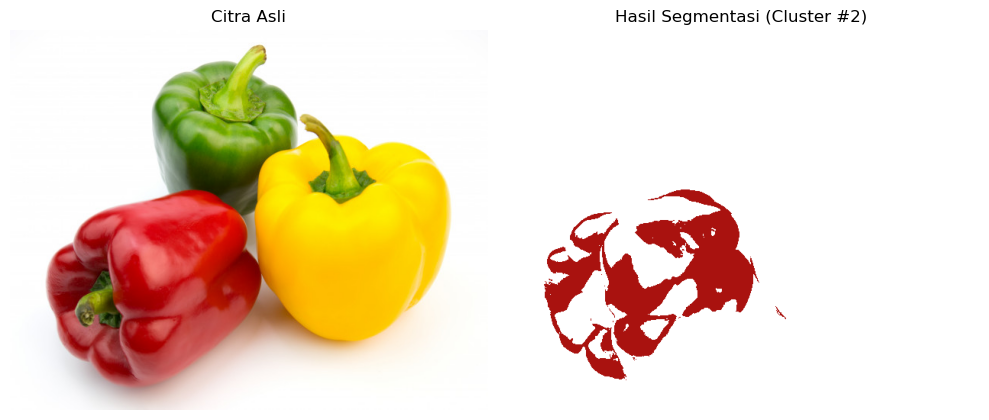

In [8]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('../images/peppers.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

pixel_vals = img_rgb.reshape((-1, 3))
pixel_vals = np.float32(pixel_vals)


k = 6  
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
_, labels, centers = cv2.kmeans(pixel_vals, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

centers = np.uint8(centers)
segmented_data = centers[labels.flatten()]
segmented_image = segmented_data.reshape(img_rgb.shape)

cluster = 1

mask = (labels.flatten() == cluster)
white_bg = np.ones_like(img_rgb, dtype=np.uint8) * 255  
white_bg = white_bg.reshape((-1, 3))
white_bg[mask] = segmented_data[mask]
random_segment = white_bg.reshape(img_rgb.shape)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(random_segment)
plt.title(f'Hasil Segmentasi (Cluster #{cluster + 1})')
plt.axis('off')

plt.tight_layout()
plt.show()


**Saat anda menampilkan warna tertentu, jelaskan kendala yang di hadapi dan mengapa hal itu terjadi**

**Jawaban:** 

Kendala utama saat menampilkan warna tertentu menggunakan metode K-Means adalah hasil segmentasi yang tidak selalu konsisten setiap kali program dijalankan. Hal ini terjadi karena algoritma K-Means memilih titik pusat awal (centroid) secara acak, sehingga pembagian cluster warna dapat berbeda pada setiap eksekusi. Selain itu, variasi pencahayaan, gradasi warna, dan kemiripan nilai warna antar piksel juga menyebabkan algoritma sulit memisahkan warna yang diinginkan secara tepat. Akibatnya, warna target kadang tercampur dengan area lain atau berubah-ubah antara percobaan, terutama jika jumlah cluster atau nilai awal acaknya tidak dikendalikan dengan seed tetap.

**Solusi:** Solusi untuk mengatasi inkonsistensi hasil segmentasi warna pada metode K-Means adalah dengan menetapkan nilai seed acak (random seed) agar inisialisasi centroid dilakukan secara deterministik, sehingga hasil pembagian cluster menjadi stabil setiap kali dijalankan. Selain itu, pemilihan jumlah cluster (k) yang tepat juga penting untuk menghasilkan pemisahan warna yang lebih akurat, karena terlalu sedikit cluster dapat membuat warna bercampur, sedangkan terlalu banyak cluster dapat memecah satu warna menjadi beberapa bagian kecil. Penggunaan ruang warna HSV juga dapat membantu karena lebih mendekati persepsi warna manusia, sehingga warna target, seperti kuning atau merah, dapat diidentifikasi dan dipisahkan dengan lebih jelas dari warna lainnya.


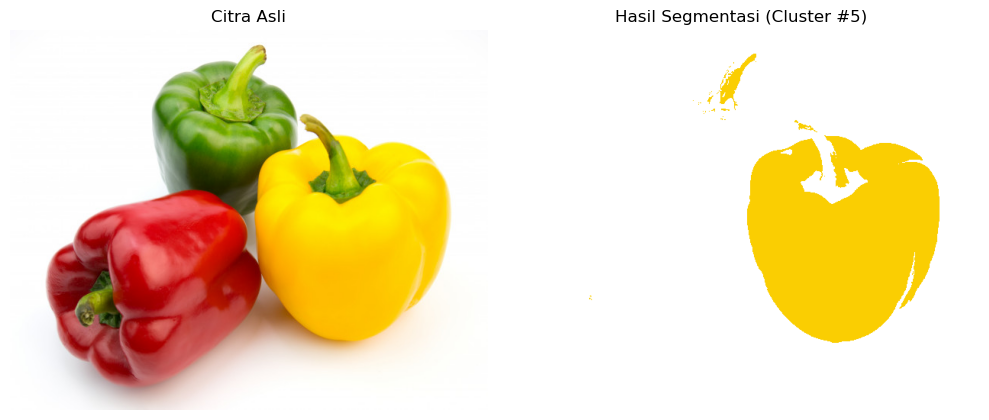

In [9]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('../images/peppers.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

pixel_vals = img_rgb.reshape((-1, 3))
pixel_vals = np.float32(pixel_vals)

# Memastikan hasil K-Means selalu sama setiap kali dijalankan
np.random.seed(42)
cv2.setRNGSeed(42)

k = 6
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
_, labels, centers = cv2.kmeans(pixel_vals, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

centers = np.uint8(centers)
segmented_data = centers[labels.flatten()]
segmented_image = segmented_data.reshape(img_rgb.shape)

cluster = 4

mask = (labels.flatten() == cluster)
white_bg = np.ones_like(img_rgb, dtype=np.uint8) * 255
white_bg = white_bg.reshape((-1, 3))
white_bg[mask] = segmented_data[mask]
random_segment = white_bg.reshape(img_rgb.shape)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(random_segment)
plt.title(f'Hasil Segmentasi (Cluster #{cluster + 1})')
plt.axis('off')

plt.tight_layout()
plt.show()


## 7. Buka File crossword.jpg. Dengan pengetahuan tentang thresholding yang sudah anda
pelajari. Lakukan thresholding biner dengan hasil terbaik menurut anda.

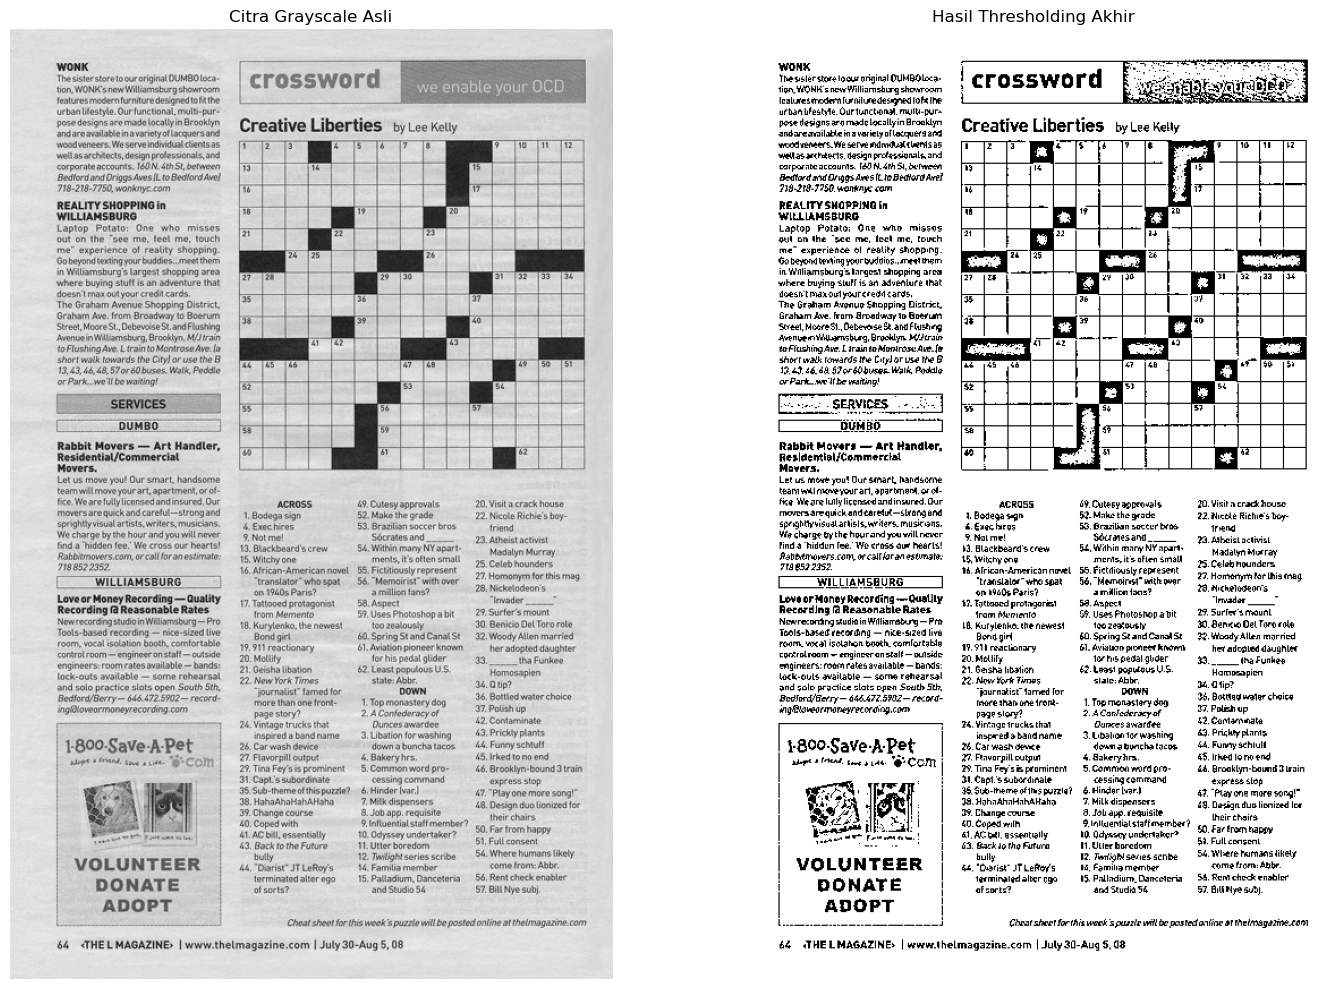

In [10]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('../images/crossword.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# mengatur kontras dan brightness untuk mengurangi noise
alpha = 1.3  
beta = 20    
adjusted = cv2.convertScaleAbs(gray, alpha=alpha, beta=beta)

thresh = cv2.adaptiveThreshold(
    adjusted,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    21, 10
)

thresh_inv = cv2.bitwise_not(thresh)

plt.figure(figsize=(15,10))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title('Citra Grayscale Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(thresh_inv, cmap='gray')
plt.title('Hasil Thresholding Akhir')
plt.axis('off')

plt.tight_layout()
plt.show()


**Penjelasan:** Metode thresholding biner terbaik yang digunakan pada citra crossword.jpg adalah dengan terlebih dahulu menyesuaikan kontras dan kecerahan (brightness) menggunakan parameter alpha dan beta sebelum melakukan proses thresholding. Penyesuaian ini bertujuan untuk memperjelas perbedaan intensitas antara area tulisan dan latar belakang, sehingga hasil segmentasi menjadi lebih tajam dan noise dapat diminimalkan tanpa mengaburkan detail teks. Selanjutnya digunakan Adaptive Gaussian Thresholding, karena metode ini mampu menyesuaikan nilai ambang secara lokal di setiap area gambar, membuat hasilnya tetap konsisten meskipun pencahayaan pada citra tidak merata. Hasil akhirnya menunjukkan tulisan yang jelas, tegas, dan kontras terhadap background putih.